# Point processes

## I. Poisson process

In [7]:
import sys
sys.path.append("../..")
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.colors import ListedColormap
import time
import json

In [8]:
with open('../../parameters/poisson-process-m-05.json', 'r') as file:
    params = json.load(file)

In [9]:
# Part 1
width, height = params['part_1']['W']
lam = params['part_1']['lam_p']
sig = params['part_1']['sig']
nu = params['part_1']['nu']

# Part 2
dx, dy = params['part_2']['dx'], params['part_2']['dy']
n_simu = params['part_2']['n_simu']
nb_x, nb_y = params['part_2']['nb_x'], params['part_2']['nb_y']
verbose = True

figure_size = (7, 7)

### 1. Generating a standard poisson process

<>:14: SyntaxWarning: invalid escape sequence '\l'
<>:14: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_912645/2800561296.py:14: SyntaxWarning: invalid escape sequence '\l'
  plt.title(f'Poisson($\lambda$ = {lam})')


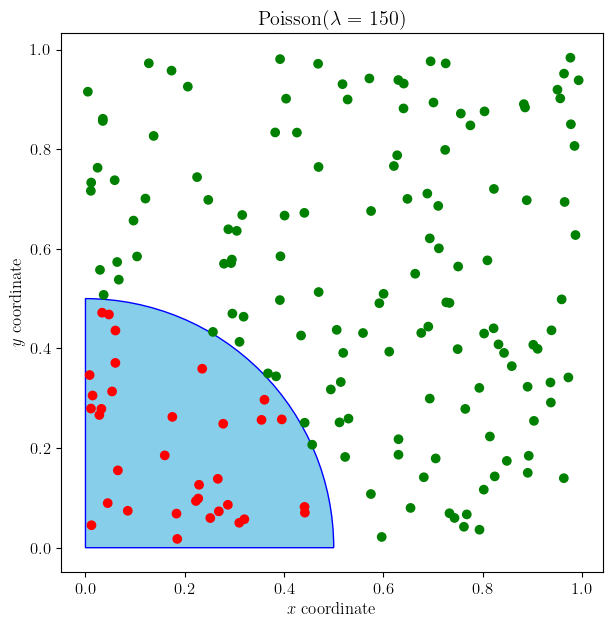

In [10]:
plt.rcParams.update({
    "text.usetex": True,          # Use LaTeX to render text
    "font.family": "serif",       # Match LaTeX serif font
    "font.size": 12
    })

m = np.random.poisson(lam*(width*height))
X = np.random.uniform([0, 0], [width, height], size=(m, 2))
fig, ax = plt.subplots(figsize=figure_size)
r = width/2
circ = patches.Wedge((0, 0), r, 0, 90, edgecolor ='blue', facecolor='skyblue', zorder = 0)
ax.scatter(X[:, 0], X[:, 1], c = ((X[:, 0]**2 + X[:, 1]**2 <= r**2)), cmap=ListedColormap(["green", "red"]))
ax.add_patch(circ)
plt.title(f'Poisson($\lambda$ = {lam})')
plt.xlabel('$x$ coordinate')
plt.ylabel('$y$ coordinate')
plt.savefig('../../img/verif-formula-1.eps', format='eps')
plt.show()

### 2. Verifying the formula $\phi(B) = \lambda \vert B \vert$

<>:14: SyntaxWarning: invalid escape sequence '\l'
<>:14: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_912645/2233831682.py:14: SyntaxWarning: invalid escape sequence '\l'
  plt.title(f'Poisson($\lambda$ = {lam})')
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


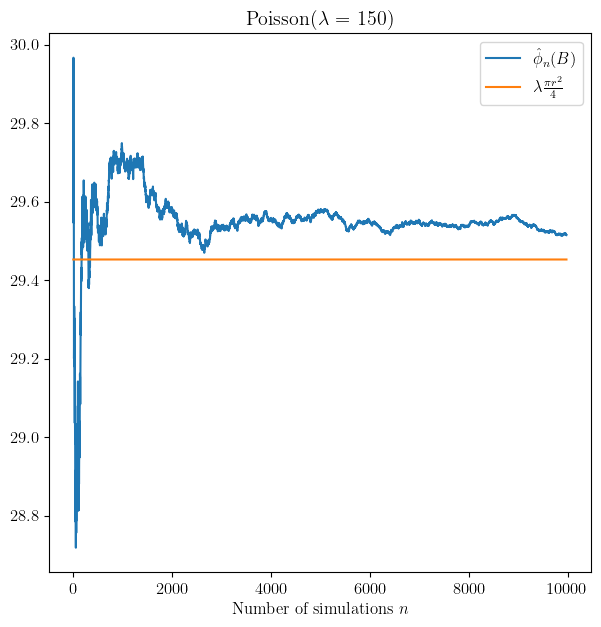

In [11]:
means = np.zeros(10000)

for i in range(10000):
    m = np.random.poisson(lam)*(width*height)
    X = np.random.uniform([0, 0], [width, height], size=(m, 2))
    means[i:] += len(X[(X[:, 0]**2 + X[:, 1]**2)<=r**2])
    
means /= list(range(1, 10000+1))

fig = plt.figure(figsize=figure_size)
plt.plot(means[25:], label = r'$\hat{\phi}_n(B)$')
plt.plot(([lam*(np.pi*r**2/4)]*10000)[25:], label = r'$\lambda \frac{\pi r^2}{4}$')
plt.xlabel(r'Number of simulations $n$')
plt.title(f'Poisson($\lambda$ = {lam})')
plt.legend()
plt.savefig('../../img/verif-formula-2.eps', format='eps')
plt.show()

## Thomas process

### 1. Generating a Thomas process

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


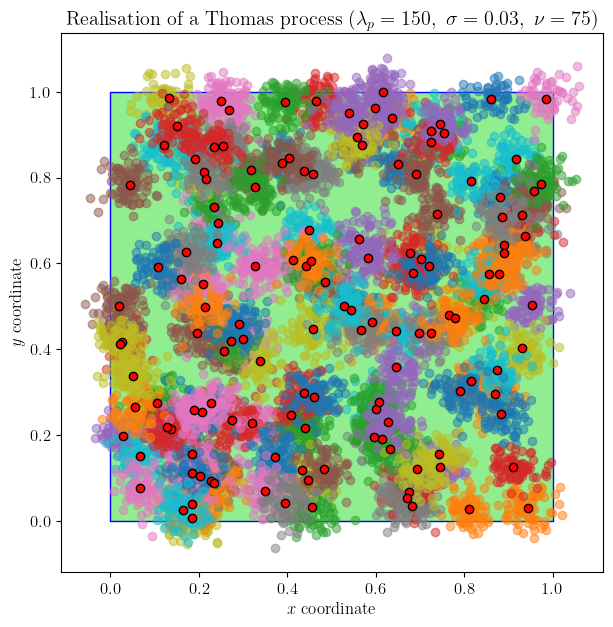

In [12]:
m = np.random.poisson(lam)*(width*height)
parents = np.random.uniform([0, 0], [width, height], size=(m, 2))
offsprings = {tuple(p): 0 for p in parents}

for i, p in enumerate(parents):
    nb_offsprings = np.random.poisson(nu)
    offsprings[tuple(p)] = np.random.normal(p, sig, (nb_offsprings, 2))

fig, ax = plt.subplots(figsize=figure_size)
for p in offsprings:
    ax.scatter(offsprings[p][:, 0], offsprings[p][:, 1], alpha=0.5)
ax.scatter(parents[:, 0], parents[:, 1], color="red", edgecolors="black")
area = patches.Rectangle((0, 0), width, height, edgecolor ='blue', facecolor='lightgreen', zorder = 0)
ax.add_patch(area)
plt.title(rf'Realisation of a Thomas process ($\lambda_p = {lam},\ \sigma = {sig},\ \nu = {nu}$)')
plt.xlabel(r'$x$ coordinate')
plt.ylabel(r'$y$ coordinate')
plt.savefig('../../img/thomas_process_init.eps', format = 'eps')
plt.show()

### 2. Pair correlation function of a Thomas process

As the p.c.f $g$ only depends on the distance $r$ between the two points $p_1$ and $p_2$, we will only compute: 
$$ g((0, 0), (x, y)) $$ 
where $(x, y)$ are the coordinates of an arbitrary point $p$.

In [60]:
def g(pt, n_simu = 10000):
    x, y = pt
    expectation = 0
    g_hist = np.zeros(n_simu)
    for j in range(n_simu):
        m = np.random.poisson(lam)*(width*height)
        parents = np.random.uniform([0, 0], [width, height], size=(m, 2))
        offsprings = {tuple(p): 0 for p in parents}

        for p in parents:
            nb_offsprings = np.random.poisson(nu)
            offsprings[tuple(p)] = np.random.normal(p, sig, (nb_offsprings, 2))
        
        all_pts = np.concatenate([parents] + list(offsprings.values()))
        
        expectation += ((abs(all_pts[:, 0])<dx/2) & (abs(all_pts[:, 1])<dy/2)).sum() * ((abs(all_pts[:, 0] - x)<dx/2) & (abs(all_pts[:, 1] - y)<dy/2)).sum()
        g_hist[j] = expectation/((j + 1) * (lam * dx * dy)**2)
        
    return g_hist


Complexity $C(n) \approx \mathcal{O}(\lambda \times width \times height \times (1 + \nu) \times n\_simu)$

In [61]:
for theta in np.linspace(1, np.pi/2-1, 5):
    pt = 0.5*np.cos(theta), 0.5*np.sin(theta)
    g_hist = g(pt, n_simu)
    plt.plot(g_hist)
plt.xlabel('Number of simulations $n$')
plt.show()

KeyboardInterrupt: 

In [ ]:
def format_time(seconds):
    days, remainder = divmod(seconds, 86400)  # 86400 seconds in a day
    hours, remainder = divmod(remainder, 3600)
    minutes, seconds = divmod(remainder, 60)
    
    if days > 0:
        return f"{days:02.0f}d {hours:02.0f}:{minutes:02.0f}:{seconds:02.0f}"
    else:
        return f"{hours:02.0f}:{minutes:02.0f}:{seconds:02.0f}"

In [ ]:
xx, yy = np.linspace(0, width, nb_x), np.linspace(0, height, nb_y)
expectation = 0
g_map = np.zeros((nb_x, nb_y))
t0 = time.time()
for k in range(n_simu):
    m = np.random.poisson(lam)*(width*height)
    parents = np.random.uniform([0, 0], [width, height], size=(m, 2))
    offsprings = {tuple(p): 0 for p in parents}

    for p in parents:
        nb_offsprings = np.random.poisson(nu)
        offsprings[tuple(p)] = np.random.normal(p, sig, (nb_offsprings, 2))
    
    all_pts = np.concatenate([parents] + list(offsprings.values()))
    for i, x in enumerate(xx):
        for j, y in enumerate(yy):
            g_map[i, j] += all_pts[(abs(all_pts[:, 0])<dx/2) & (abs(all_pts[:, 1])<dy/2)].sum() + all_pts[(abs(all_pts[:, 0] - x)<dx/2) & (abs(all_pts[:, 1] - y)<dy/2)].sum()
    
    if verbose:
        iterations_left = n_simu - (k+1)
        elapsed_time = time.time() - t0
        avg_time_per_iteration = elapsed_time/(k+1)
        remaining_time = avg_time_per_iteration*(n_simu - (k+1))
        print(f"Iteration {(k+1)}/{n_simu} | Elapsed: {format_time(elapsed_time)} | Estimated Remaining: {format_time(remaining_time)}")
       
g_map /= n_simu * (lam * dx * dy)**2

plt.imshow(g_map, cmap="viridis", interpolation="nearest")
plt.colorbar()
plt.title(r'Heatmap of the p.c.f $g$')
plt.show()

Iteration 1/10000 | Elapsed: 00:00:00 | Estimated Remaining: 00:20:38
Iteration 2/10000 | Elapsed: 00:00:00 | Estimated Remaining: 00:19:36
Iteration 3/10000 | Elapsed: 00:00:00 | Estimated Remaining: 00:18:54
Iteration 4/10000 | Elapsed: 00:00:00 | Estimated Remaining: 00:18:15
Iteration 5/10000 | Elapsed: 00:00:01 | Estimated Remaining: 00:17:40
Iteration 6/10000 | Elapsed: 00:00:01 | Estimated Remaining: 00:17:36
Iteration 7/10000 | Elapsed: 00:00:01 | Estimated Remaining: 00:17:40
Iteration 8/10000 | Elapsed: 00:00:01 | Estimated Remaining: 00:17:39
Iteration 9/10000 | Elapsed: 00:00:01 | Estimated Remaining: 00:17:43
Iteration 10/10000 | Elapsed: 00:00:01 | Estimated Remaining: 00:17:47
Iteration 11/10000 | Elapsed: 00:00:01 | Estimated Remaining: 00:17:50
Iteration 12/10000 | Elapsed: 00:00:01 | Estimated Remaining: 00:17:57
Iteration 13/10000 | Elapsed: 00:00:01 | Estimated Remaining: 00:17:56
Iteration 14/10000 | Elapsed: 00:00:02 | Estimated Remaining: 00:17:50
Iteration 15/10

KeyboardInterrupt: 

In [ ]:
np.savetxt("pcf.csv", g_map, delimiter=",", fmt="%d")